In [24]:
import astropy as ap
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import os

from astropy import units as u
from astropy import constants as apc
from IPython import display
from time import time
from tqdm.notebook import trange

os.environ['CUPY_DUMP_CUDA_SOURCE_ON_ERROR'] = '1'

In [25]:
G = apc.G.to(u.kpc**3 / u.yr**2 / u.solMass)  # 4.4985e-24
G_flt = float(G * u.yr**2 * u.solMass / u.kpc**3)
N = 4
N_blocks = 1
N_threads = 4
dt = 1e3


milky_way_potential = cp.RawKernel(r'''
extern "C" __global__
void milky_way_potential(const double q[][6], double q_dot[][6]) {
    double nucl_m = 1.71e9;
    double nucl_a = 0.07;
    double bulge_m = 5e9;
    double bulge_a = 1.;
    double disk_m = 6.8e10;
    double disk_a = 3.;
    double disk_b = 0.28;
    double halo_m = 5.4e11;
    double halo_a = 15.62;
    double G = %s;
    
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i >= %d)
        return;
    
    double r = sqrt(q[i][0]*q[i][0] + q[i][1]*q[i][1] + q[i][2]*q[i][2]);
    double sqrtz = sqrt(q[i][2]*q[i][2] + disk_b*disk_b);
    double zd = disk_a + sqrtz;
    double tmp = G * disk_m * pow(q[i][0]*q[i][0] + q[i][1]*q[i][1] + zd*zd, -1.5);

    for (int j = 0; j < 3; j++) {
        q_dot[i][j] = q[i][j+3];
    
        q_dot[i][j+3] = -G * nucl_m / (r * (r+nucl_a) * (r+nucl_a)) * q[i][j];
        q_dot[i][j+3] -= G * bulge_m / (r * (r+bulge_a) * (r+bulge_a)) * q[i][j];
        q_dot[i][j+3] -= G * halo_m * (log(1 + r/halo_a) - r/(r + halo_a)) / (r*r*r) * q[i][j];

        q_dot[i][j+3] -= tmp * q[i][j] * ( j==2 ? (1 + disk_a/sqrtz) : 1);
    }
}
''' % (G_flt, N), 'milky_way_potential')


n_body_potential = cp.RawKernel(r'''
extern "C" __global__
void n_body_potential(const double m[], const double q[][6], double q_dot[][6]) {
    double G = %s;
    
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    int n = blockDim.y * blockIdx.y + threadIdx.y;
    
    if (i >= %d or n >= %d)
        return;
    
    if (n == i)
        return;

    double r2 = 0;
    for (int k = 0; k < 3; k++)
        r2 += (q[i][k] - q[n][k]) * (q[i][k] - q[n][k]);

    for (int k = 0; k < 3; k++)
        q_dot[i][k+3] -= G * m[n] * (q[i][k] - q[n][k]) / (r2 * sqrt(r2));
}
''' % (G_flt, N, N), 'n_body_potential')


# mislim da se korištenjem ovoga potencijal galaksije računa N puta
# rješenje bi moglo biti računanje potencijala čestica sekvencijalno no to je strašno neefikasno
# mislim da je za velike N brži pristup onaj koji koristi 2 kernela umjesto ovoga
potential = cp.RawKernel(r'''
extern "C" __global__
void potential(const double m[], const double q[][6], double q_dot[][6]) {
    double nucl_m = 1.71e9;
    double nucl_a = 0.07;
    double bulge_m = 5e9;
    double bulge_a = 1.;
    double disk_m = 6.8e10;
    double disk_a = 3.;
    double disk_b = 0.28;
    double halo_m = 5.4e11;
    double halo_a = 15.62;
    double G = %s;
    
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    int n = blockDim.y * blockIdx.y + threadIdx.y;
    
    if (i >= %d or n >= %d)
        return;
    
    double r = sqrt(q[i][0]*q[i][0] + q[i][1]*q[i][1] + q[i][2]*q[i][2]);
    double sqrtz = sqrt(q[i][2]*q[i][2] + disk_b*disk_b);
    double zd = disk_a + sqrtz;
    double tmp = G * disk_m * pow(q[i][0]*q[i][0] + q[i][1]*q[i][1] + zd*zd, -1.5);

    for (int j = 0; j < 3; j++) {
        q_dot[i][j] = q[i][j+3];
    
        q_dot[i][j+3] = -G * nucl_m / (r * (r+nucl_a) * (r+nucl_a)) * q[i][j];
        q_dot[i][j+3] -= G * bulge_m / (r * (r+bulge_a) * (r+bulge_a)) * q[i][j];
        q_dot[i][j+3] -= G * halo_m * (log(1 + r/halo_a) - r/(r + halo_a)) / (r*r*r) * q[i][j];

        q_dot[i][j+3] -= tmp * q[i][j] * ( j==2 ? (1 + disk_a/sqrtz) : 1);
    }

    if (n == i)
        return;

    double r2 = 0;
    for (int k = 0; k < 3; k++)
        r2 += (q[i][k] - q[n][k]) * (q[i][k] - q[n][k]);

    for (int k = 0; k < 3; k++)
        q_dot[i][k+3] -= G * m[n] * (q[i][k] - q[n][k]) / (r2 * sqrt(r2));
}
''' % (G_flt, N, N), 'potential')

# time_step_cuda = cp.RawKernel(r'''
# extern "C" __global__
# void time_step_cuda(const double m[], const double q[][6], double p[][6]) {
#     int N = %d;
#     double dt = %s;
    
#     double q_dot1[N][6];
#     milky_way_potential(q, q_dot1);
#     n_body_potential(m, q, q_dot1);
    
#     double q_tmp[N][6];
#     for (int j = 0; j < N; j++)
#         for (int k = 0; k < 6; k++)
#             q_tmp[j][k] = q[j][k] + dt * q_dot1[j][k];
            
#     double q_dot2[N][6];
#     milky_way_potential(q_tmp, q_dot2);
#     n_body_potential(m, q_tmp, q_dot2);
    
#     for (int j = 0; j < N; j++)
#         for (int k = 0; k < 6; k++)
#             p[j][k] = q[j][k] + dt/2 * (q_dot1[j][k] + q_dot2[j][k]);
# }
# ''' % (N, dt), 'time_step_cuda')


def time_derivative(m, q, q_dot):
    milky_way_potential((N_blocks,), (N_threads,), (q, q_dot))
    n_body_potential((N_blocks, N_blocks), (N_threads, N_threads), (m, q, q_dot))
#     potential((N_blocks, N_blocks), (N_threads, N_threads), (m, q, q_dot))
    
    
def time_step(m, q):
    # first iteration prediction
    q_dot1 = cp.zeros_like(q)
    time_derivative(m, q, q_dot1)
    q_tmp = q + dt * q_dot1
    
    # second iteration
    q_dot2 = cp.zeros_like(q)
    time_derivative(m, q_tmp, q_dot2)
    
    return q + dt/2 * (q_dot1 + q_dot2)


def print_time(start_time, loop_i, loop_length):
    progress = loop_i/loop_length
    est_time = (1/progress - 1) * (time() - start_time)
    print(f'Progress: {100*progress:.0f}%\t Estimated time left: {est_time:.0f}s', end='\t ')
    print('|'*int(progress*50 - 1) + '\\' + '_'*int(50 - progress*50))

In [32]:
masses = cp.array([100., 20., 0.7, 4.])
q_init = cp.array([[-3.09, 2.00, 0.01, -1e-12, -2.00e-7, 1e-7],
                   [-3.04, 2.05, 0.03, -1e-12, -2.00e-7, 1e-7],
                   [-3.03, 2.16, 0.08, -1e-12, -2.00e-7, 1e-7],
                   [-3.00, 2.02, 0.07, -1e-12, -2.00e-7, 1e-7]
                  ])

T = 5e8
N_pts = int(T/dt)
ts = np.arange(0, T, dt)
qs = cp.zeros((N_pts, N, 6))
qs[0] = q_init
q = q_init

start_time = time()
for i in trange(N_pts-1, miniters=10000):
    q = time_step(masses, q)
    qs[i+1] = q[:]
    
#     if i % 10000 == 1:
#         print_time(start_time, i, N_pts)

print(f'Total time: {time() - start_time:.0f}s')
qs = cp.asnumpy(qs)

  0%|          | 0/499999 [00:00<?, ?it/s]

Total time: 113s


Text(0, 0.5, 'y')

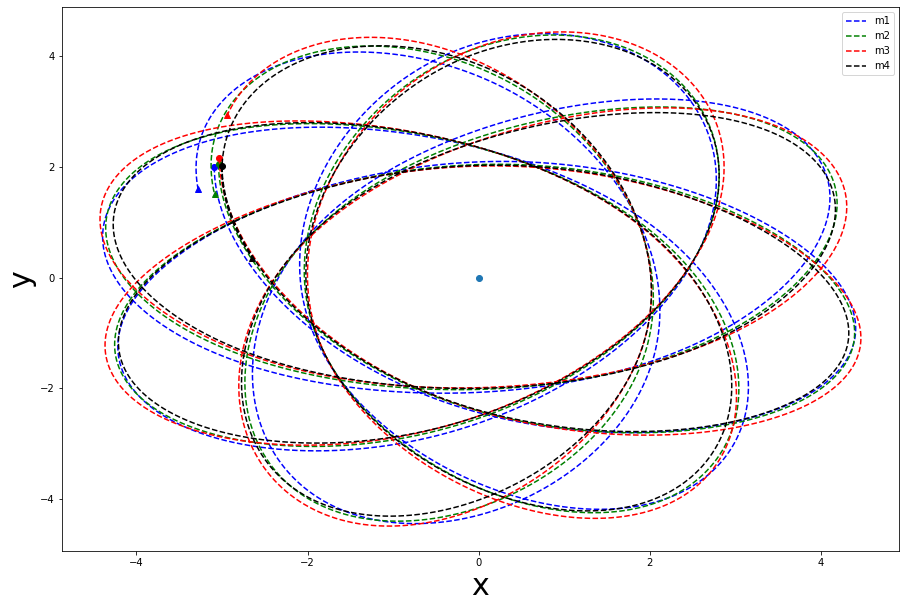

In [14]:
colors = ['b', 'g', 'r', 'k']

plt.figure(figsize=(15, 10))
for i in range(4):
    plt.plot(qs[:, i, 0], qs[:, i, 1], '--', color=colors[i], label=f'm{i+1}')
    plt.plot(qs[0, i, 0], qs[0, i, 1], 'o', color=colors[i])
    plt.plot(qs[-1, i, 0], qs[-1, i, 1], '^', color=colors[i])
    
plt.scatter(0, 0)
plt.legend()
plt.xlabel('x', fontsize=30)
plt.ylabel('y', fontsize=30)

Text(0, 0.5, 'z')

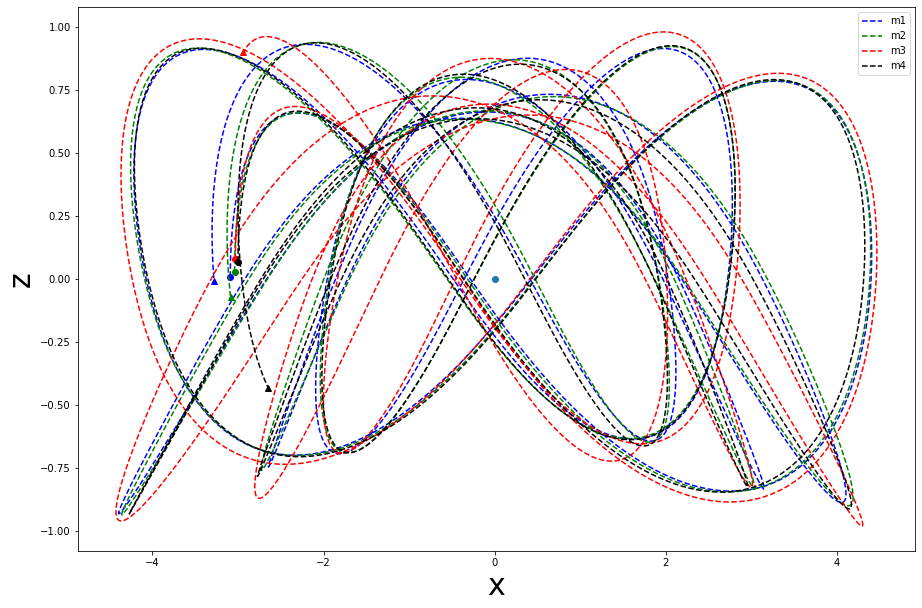

In [15]:
plt.figure(figsize=(15, 10))
for i in range(4):
    plt.plot(qs[:, i, 0], qs[:, i, 2], '--', color=colors[i], label=f'm{i+1}')
    plt.plot(qs[0, i, 0], qs[0, i, 2], 'o', color=colors[i])
    plt.plot(qs[-1, i, 0], qs[-1, i, 2], '^', color=colors[i])
    
plt.scatter(0, 0)
plt.legend()
plt.xlabel('x', fontsize=30)
plt.ylabel('z', fontsize=30)

Text(0, 0.5, 'z')

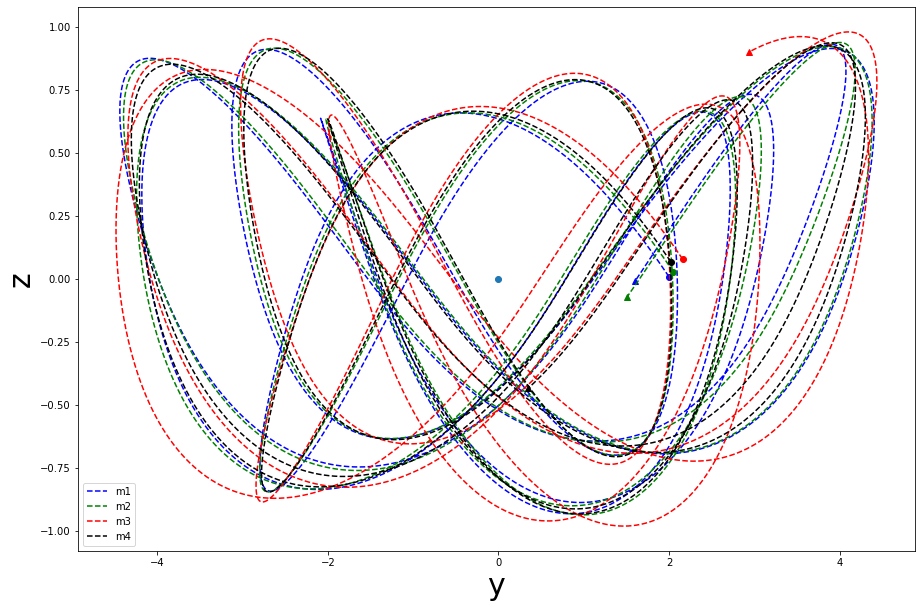

In [16]:
plt.figure(figsize=(15, 10))
for i in range(4):
    plt.plot(qs[:, i, 1], qs[:, i, 2], '--', color=colors[i], label=f'm{i+1}')
    plt.plot(qs[0, i, 1], qs[0, i, 2], 'o', color=colors[i])
    plt.plot(qs[-1, i, 1], qs[-1, i, 2], '^', color=colors[i])
    
plt.scatter(0, 0)
plt.legend()
plt.xlabel('y', fontsize=30)
plt.ylabel('z', fontsize=30)

Text(0, 0.5, '$z$')

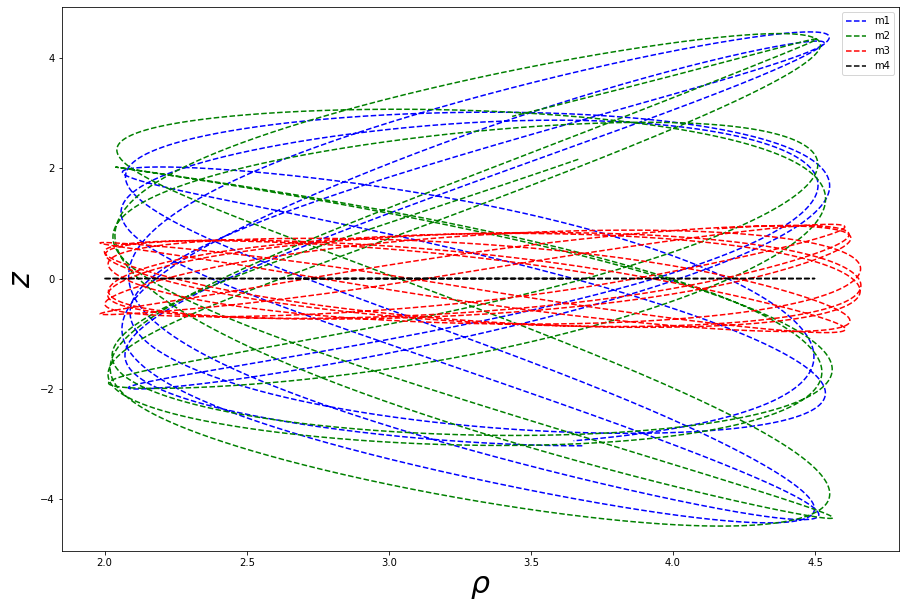

In [17]:
rhos = np.sqrt(qs[:, :, 0]**2 + qs[:, :, 1]**2)
plt.figure(figsize=(15, 10))
plt.plot(rhos[:, 0], qs[:, 2, 0], 'b--', label='m1')
plt.plot(rhos[:, 1], qs[:, 2, 1], 'g--', label='m2')
plt.plot(rhos[:, 2], qs[:, 2, 2], 'r--', label='m3')
plt.plot(rhos[:, 3], qs[:, 2, 3], 'k--', label='m4')
plt.scatter(0, 0)
plt.legend()
plt.xlabel('$\\rho$', fontsize=30)
plt.ylabel('$z$', fontsize=30)

Text(0.5, 0, '$t$ [yr]')

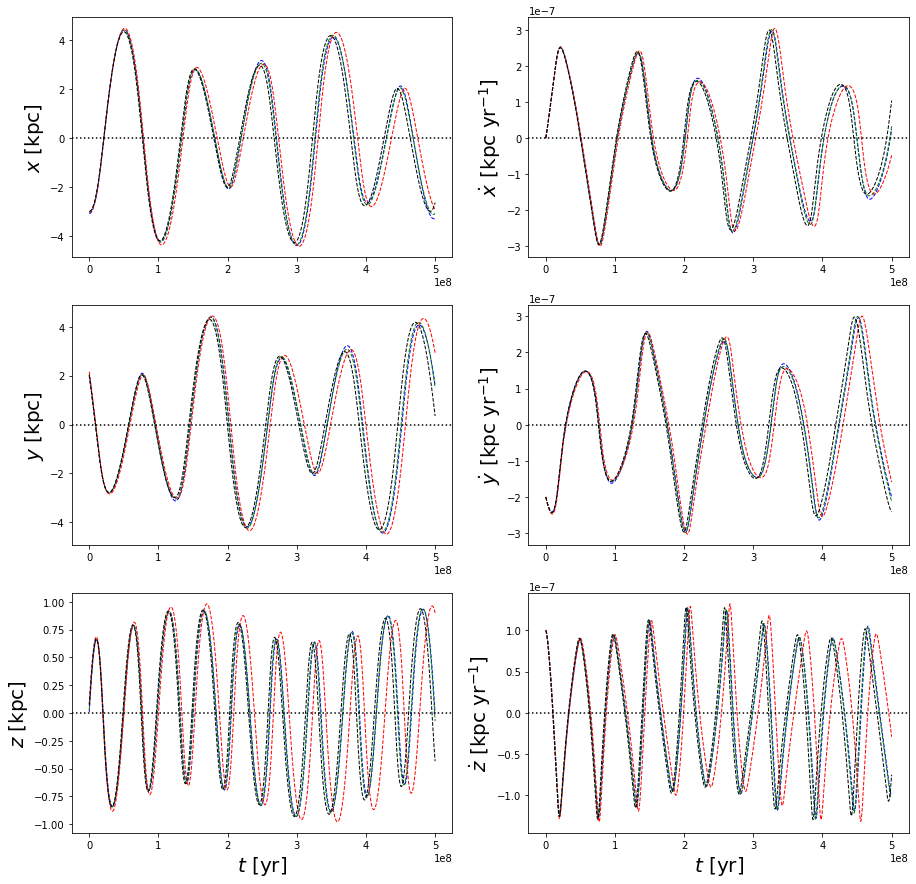

In [33]:
fig, ax = plt.subplots(3, 2, figsize=(15, 15))
xyz = ('x', 'y', 'z')
labels = [ f'${l}$ [kpc]' for l in xyz ] + [ f'$\dot{l}$ [kpc yr$^{{-1}}$]' for l in xyz ]

for i in range(3):
    for j in range(4):
        ax[i, 0].plot(ts, qs[:, j, i], '--', c=colors[j], lw=1)
    ax[i, 0].set_ylabel(labels[i], fontsize=20)
    ax[i, 0].axhline(0, c='k', ls=':')
    
for i in range(3):
    for j in range(4):
        ax[i, 1].plot(ts, qs[:, j, i+3], '--', c=colors[j], lw=1)
    ax[i, 1].set_ylabel(labels[i+3], fontsize=20)
    ax[i, 1].axhline(0, c='k', ls=':')
    
ax[2, 0].set_xlabel('$t$ [yr]', fontsize=20)
ax[2, 1].set_xlabel('$t$ [yr]', fontsize=20)

Maximum energy deviation of the system: 0.23%


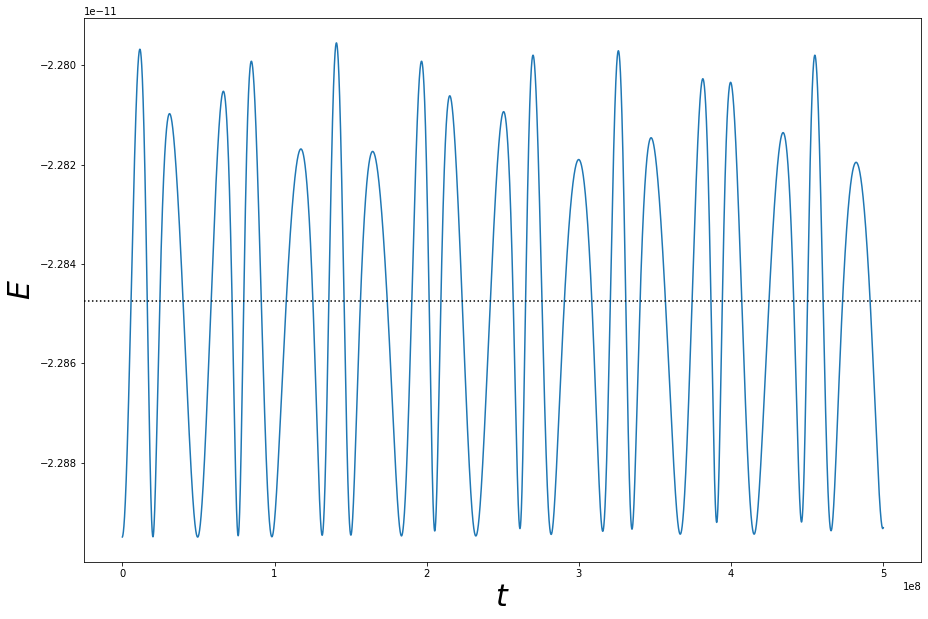

In [11]:
energy_stability = cp.RawKernel(r'''
extern "C" __global__
void energy_stability(const double m[], const double q[][%d][6], double E[]) {
    double nucl_m = 1.71e9;
    double nucl_a = 0.07;
    double bulge_m = 5e9;
    double bulge_a = 1.;
    double disk_m = 6.8e10;
    double disk_a = 3.;
    double disk_b = 0.28;
    double halo_m = 5.4e11;
    double halo_a = 15.62;
    double G = %s;
    
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i > %d) return;
    E[i] = 0;
    int k;
    
    for (int j = 0; j < %d; j++) {
        double r = sqrt(q[i][j][0]*q[i][j][0] + q[i][j][1]*q[i][j][1] + q[i][j][2]*q[i][j][2]);
        double sqrtz = sqrt(q[i][j][2]*q[i][j][2] + disk_b*disk_b);
        double zd = disk_a + sqrtz;
        
        E[i] -= G * m[j] * bulge_m / (r + bulge_a);
        E[i] -= G * m[j] * nucl_m / (r + nucl_a);
        E[i] -= G * m[j] * disk_m / sqrt(r*r + zd*zd);
        E[i] -= G * m[j] * halo_m * log(1 + r/halo_a)/r;
        
        for (k = 0; k < %d; k++) {
            if (k == j) continue;
                
            double r2 = 0;
            for (int l = 0; l < 3; l++)
                r2 += (q[i][j][l] - q[i][k][l]) * (q[i][j][l] - q[i][k][l]);
            
            E[i] -= G * m[j] * m[k] / sqrt(r2);
        }
        
        for (k = 3; k < 6; k++)
            E[i] += 0.5 * m[j] * q[i][j][k] *q[i][j][k];
    }
}
''' % (N, G_flt, N_pts, N, N), 'energy_stability')

E = cp.zeros((N_pts,))
qs = cp.asarray(qs)

energy_stability((1000,), (500,), (masses, qs, E))

qs = cp.asnumpy(qs)
E = cp.asnumpy(E)

plt.figure(figsize=(15, 10))
plt.plot(ts, E)
plt.xlabel('$t$', fontsize=30)
plt.ylabel('$E$', fontsize=30)

avg = sum(E)/N_pts
plt.axhline(avg, ls=':', c='k')

max_deviation = max(max(E) - avg, avg - min(E))/(-avg)
print(f'Maximum energy deviation of the system: {max_deviation*100:.2f}%')